#  Predict Future Stock Prices Using Machine Learning

---

**Project Type:** Supervised Machine Learning Regression

**Stock:** Tesla Inc. (TSLA)

**Data Source:** Yahoo Finance

**Models Used:**
- Linear Regression
- Random Forest Regressor

---

##  Objective

This project demonstrates how to use historical stock market data to predict the next day's closing price for Tesla (TSLA) stock. We will walk through the complete ML pipeline from data collection to model evaluation.

---

##  Sections

1. [Problem Statement](#1-problem-statement)
2. [Import Libraries](#2-import-libraries)
3. [Install & Load Dataset](#3-install--load-dataset)
4. [Data Exploration](#4-data-exploration)
5. [Data Visualization](#5-data-visualization)
6. [Feature Engineering](#6-feature-engineering)
7. [Model Training](#7-model-training)
8. [Model Evaluation](#8-model-evaluation)
9. [Results Visualization](#9-results-visualization)
10. [Conclusion](#10-conclusion)

<a name="1-problem-statement"></a>
# 1. Problem Statement

---

**Business Context:**

Stock price prediction is one of the most challenging and valuable applications of machine learning in finance. Investors and traders rely on accurate price forecasts to make informed buy/sell decisions.

**Technical Problem:**

Given historical daily stock data (Open, High, Low, Volume), can we train a machine learning model to predict the **next day's closing price**?

**Approach:**

- **Input Features:** Open price, High price, Low price, Trading Volume
- **Target Variable:** Next day's Close price (created by shifting Close price by -1 day)
- **Models:** Linear Regression (baseline) and Random Forest Regressor (ensemble method)
- **Evaluation Metrics:** MAE, RMSE, R² Score

**Why These Features?**

- **Open:** Starting price indicates market sentiment at opening bell
- **High/Low:** Shows the daily trading range and volatility
- **Volume:** Trading activity often precedes significant price movements

---

<a name="2-import-libraries"></a>
# 2. Import Libraries

---

We need three categories of libraries:

| Category | Purpose | Libraries |
|----------|---------|-----------|
| **Data** | Download and handle stock data | `yfinance`, `pandas`, `numpy` |
| **ML** | Model training and evaluation | `scikit-learn` |
| **Viz** | Data visualization | `matplotlib`, `seaborn` |

---

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler          # Added for feature scaling
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("\u2705 All libraries imported successfully!")


✅ All libraries imported successfully!


<a name="3-install--load-dataset"></a>
# 3. Install & Load Dataset

---

### 3.1 Install yfinance

Google Colab may not have `yfinance` pre-installed. We use `pip` to install it.

> **Note:** The `-q` flag suppresses installation output for cleaner display.

### 3.2 Download Tesla (TSLA) Stock Data

- **Ticker Symbol:** TSLA (Tesla Inc.)
- **Period:** 5+ years (2019-01-01 to 2024-12-31)
- **Source:** Yahoo Finance via `yfinance` library

The `yfinance` library provides a convenient Python interface to download historical market data from Yahoo Finance.

---

In [21]:
# ============================================================
# INSTALL YFINANCE (if not already installed in Colab)
# ============================================================
# The -q flag makes the installation quiet (less output)
!pip install -q yfinance

# Now import yfinance after installation
import yfinance as yf

print(" yfinance installed and imported successfully!")

 yfinance installed and imported successfully!


In [22]:
# ============================================================
# DOWNLOAD TESLA (TSLA) STOCK DATA
# ============================================================

# Define the stock ticker symbol for Tesla
ticker = "TSLA"

# Define the date range for historical data (5+ years)
start_date = "2019-01-01"
end_date = "2024-12-31"

print(f" Downloading {ticker} stock data from {start_date} to {end_date}...")
print(" Please wait, this may take a few seconds...")

# Download the historical stock data using yfinance
# yfinance.Ticker().history() returns a DataFrame with OHLCV data
stock_data = yf.Ticker(ticker).history(start=start_date, end=end_date)

print(f"\n Successfully downloaded {len(stock_data)} trading days of data!")

 Please wait, this may take a few seconds...

 Successfully downloaded 1509 trading days of data!


<a name="4-data-exploration"></a>
# 4. Data Exploration

---

Before building any ML model, we must understand our data. This section covers:

- **Shape & Structure:** How many rows and columns do we have?
- **Column Info:** What data types and missing values exist?
- **Statistical Summary:** Mean, min, max, and quartiles of each feature
- **Missing Values:** Data quality check

---

In [23]:
# ============================================================
# 4.1 DISPLAY FIRST 5 ROWS
# ============================================================
# head() shows the first 5 rows - gives a quick look at the data structure
print(" First 5 rows of the dataset:")
stock_data.head()

 First 5 rows of the dataset:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-01-02 00:00:00-05:00,20.406668,21.008667,19.920000,20.674667,174879000,0.0,0.0
2019-01-03 00:00:00-05:00,20.466667,20.626667,19.825333,20.024000,104478000,0.0,0.0
2019-01-04 00:00:00-05:00,20.400000,21.200001,20.181999,21.179333,110911500,0.0,0.0
2019-01-07 00:00:00-05:00,21.448000,22.449333,21.183332,22.330667,113268000,0.0,0.0
2019-01-08 00:00:00-05:00,22.797333,22.934000,21.801332,22.356667,105127500,0.0,0.0


In [24]:
# ============================================================
# 4.2 DATASET SHAPE AND COLUMNS
# ============================================================

print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total Trading Days (Rows): {stock_data.shape[0]}")
print(f"Number of Features (Columns): {stock_data.shape[1]}")
print(f"\nColumn Names: {list(stock_data.columns)}")
print(f"\nDate Range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
print(f"Total Years: {(stock_data.index.max() - stock_data.index.min()).days / 365.25:.1f}")

📊 DATASET OVERVIEW
Total Trading Days (Rows): 1509
Number of Features (Columns): 7

Column Names: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

Date Range: 2019-01-02 to 2024-12-30
Total Years: 6.0


In [25]:
# ============================================================
# 4.3 DATA TYPES AND MISSING VALUES
# ============================================================

print(" DATA TYPES:")
print(stock_data.dtypes)

print("\n" + "=" * 50)
print(" MISSING VALUES CHECK:")
missing = stock_data.isnull().sum()
print(missing)

# Check if any missing values exist
if missing.sum() == 0:
    print("\n No missing values found in the dataset!")
else:
    print(f"\n Found {missing.sum()} missing values. We'll handle these in preprocessing.")

 DATA TYPES:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

 MISSING VALUES CHECK:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

 No missing values found in the dataset!


In [26]:
# ============================================================
# 4.4 STATISTICAL SUMMARY
# ============================================================
# describe() provides count, mean, std, min, 25%, 50%, 75%, max
print(" STATISTICAL SUMMARY OF NUMERIC COLUMNS:")
print("=" * 70)
stock_data.describe().round(2)

 STATISTICAL SUMMARY OF NUMERIC COLUMNS:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1509.00,1509.00,1509.00,1509.00,1.509000e+03,1509.0,1509.00
mean,180.73,184.78,176.43,180.71,1.275475e+08,0.0,0.01
std,105.36,107.69,102.76,105.26,8.052966e+07,0.0,0.15
min,12.07,12.45,11.80,11.93,2.940180e+07,0.0,0.00
25%,72.20,75.69,72.03,74.64,7.801200e+07,0.0,0.00
50%,202.06,207.20,198.26,202.07,1.044233e+08,0.0,0.00
75%,250.77,255.39,244.84,251.12,1.491588e+08,0.0,0.00
max,475.90,488.54,457.51,479.86,9.140820e+08,0.0,5.00


<a name="5-data-visualization"></a>
# 5. Data Visualization

---

Visual analysis helps us understand patterns in the data before modeling. We create:

1. **Closing Price Trend** - Shows how TSLA stock price evolved over 5+ years
2. **Correlation Heatmap** - Reveals relationships between features (important for feature selection)

---

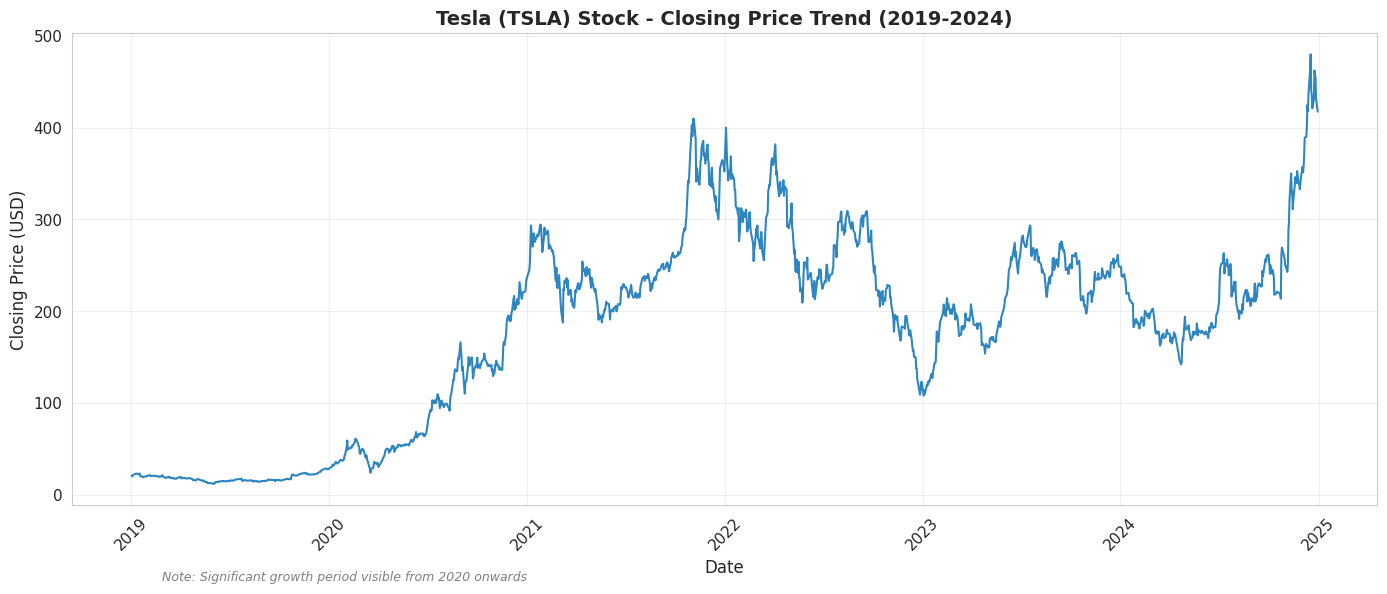


📊 INSIGHT: The chart shows Tesla's dramatic price appreciation, especially during 2020-2021.


In [27]:
# ============================================================
# 5.1 CLOSING PRICE TREND GRAPH
# ============================================================

plt.figure(figsize=(14, 6))  # Set figure size (width=14, height=6)

# Plot the closing price over time
plt.plot(stock_data.index, stock_data['Close'], linewidth=1.5, color='#2E86C1')

# Add title and labels with professional formatting
plt.title('Tesla (TSLA) Stock - Closing Price Trend (2019-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Tight layout prevents label cutoff
plt.tight_layout()

# Add annotation for key insight
plt.figtext(0.12, 0.02, "Note: Significant growth period visible from 2020 onwards",
            fontsize=9, style='italic', color='gray')

plt.show()

print("\n📊 INSIGHT: The chart shows Tesla's dramatic price appreciation, especially during 2020-2021.")

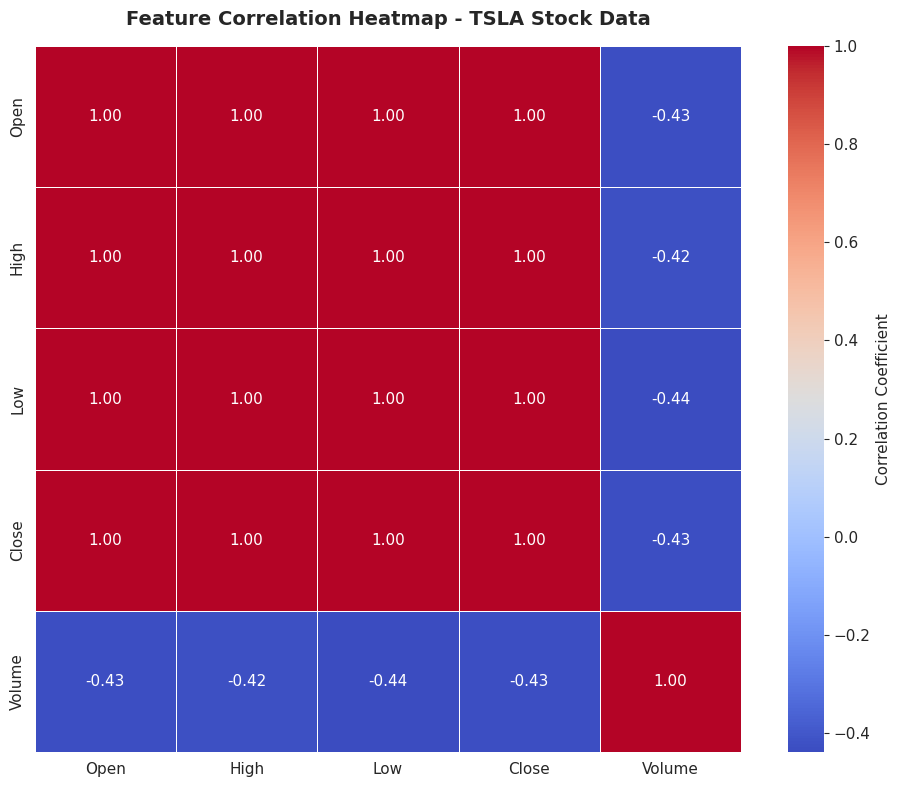


 INSIGHT: Open, High, Low, and Close are highly correlated (>.99), which is expected.
   Volume shows weaker correlation with price features, providing additional signal.


In [28]:
# ============================================================
# 5.2 CORRELATION HEATMAP
# ============================================================

# Select only the columns we'll use for modeling
# We exclude 'Stock Splits' and 'Dividends' as they are not features for prediction
features_for_corr = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Calculate correlation matrix
correlation_matrix = features_for_corr.corr()

plt.figure(figsize=(10, 8))

# Create heatmap with annotations
# annot=True displays the correlation values in each cell
# cmap='coolwarm' provides a color gradient (blue=negative, red=positive)
# fmt='.2f' formats numbers to 2 decimal places
sns.heatmap(correlation_matrix,
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Color scheme
            fmt='.2f',            # Number format
            linewidths=0.5,       # Border between cells
            square=True,          # Make cells square
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Feature Correlation Heatmap - TSLA Stock Data', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n INSIGHT: Open, High, Low, and Close are highly correlated (>.99), which is expected.")
print("   Volume shows weaker correlation with price features, providing additional signal.")

<a name="6-feature-engineering"></a>
# 6. Feature Engineering

---

Feature engineering transforms raw data into a format suitable for ML models.

### Steps:

1. **Select Features:** Extract only the columns we need (Open, High, Low, Volume)
2. **Create Target Variable:** Shift the Close price by -1 to get 'next day close'
3. **Handle Missing Values:** Drop rows with NaN (the last row will have NaN target)
4. **Train-Test Split:** Split into 80% training, 20% testing data

**Why shift by -1?**
- We want to predict tomorrow's close using today's data
- `df['Close'].shift(-1)` moves each close price up by one row
- The last row will have NaN (no tomorrow) and gets dropped

---

In [29]:
# ============================================================
# 6.1 SELECT FEATURES AND CREATE TARGET VARIABLE
# ============================================================

# Step 1: Select input features (X)
# We use Open, High, Low, and Volume to predict next day's close
feature_columns = ['Open', 'High', 'Low', 'Volume']
X = stock_data[feature_columns].copy()

# Step 2: Create target variable (y) - Next day's closing price
# shift(-1) moves the Close price up by one row
# This means: today's features predict tomorrow's close
y = stock_data['Close'].shift(-1)

print("🔧 FEATURE ENGINEERING COMPLETE")
print("=" * 50)
print(f" Features (X) shape: {X.shape}")
print(f" Target (y) shape: {y.shape}")
print(f"\n Feature Columns: {feature_columns}")
print(f" Target: Next Day Close Price")

🔧 FEATURE ENGINEERING COMPLETE
 Features (X) shape: (1509, 4)
 Target (y) shape: (1509,)

 Feature Columns: ['Open', 'High', 'Low', 'Volume']
 Target: Next Day Close Price


In [30]:
# ============================================================
# 6.2 HANDLE MISSING VALUES
# ============================================================

print("\U0001f50d CHECKING FOR MISSING VALUES AFTER TARGET CREATION:")

print(f"\nMissing in Features (X):\n{X.isnull().sum()}")
print(f"\nMissing in Target (y): {y.isnull().sum()}")

# FIX 2: Drop last row directly — avoids index-alignment edge cases
# shift(-1) creates exactly 1 NaN at the end, so removing last row is safe
X_clean = X.iloc[:-1].copy()
y_clean = y.iloc[:-1].copy()

print(f"\n\u2705 After cleaning - Features shape: {X_clean.shape}")
print(f"\u2705 After cleaning - Target shape: {y_clean.shape}")
print(f"\n\U0001f5d1\ufe0f  Dropped 1 row with missing target value")


🔍 CHECKING FOR MISSING VALUES AFTER TARGET CREATION:

Missing in Features (X):
Open      0
High      0
Low       0
Volume    0
dtype: int64

Missing in Target (y): 1

✅ After cleaning - Features shape: (1508, 4)
✅ After cleaning - Target shape: (1508,)

🗑️  Dropped 1 row with missing target value


In [31]:
# ============================================================
# 6.3 TRAIN-TEST SPLIT
# ============================================================

# Split data: 80% for training, 20% for testing
# random_state=42 ensures reproducibility (same split every time)
# shuffle=False is important for time series (maintains chronological order)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,       # 20% for testing
    random_state=42,     # For reproducibility
    shuffle=False        # Keep time order intact (crucial for stocks!)
)

print("  TRAIN-TEST SPLIT COMPLETE")
print("=" * 50)
print(f" Training samples: {len(X_train)} ({len(X_train)/len(X_clean)*100:.1f}%)")
print(f" Testing samples:  {len(X_test)} ({len(X_test)/len(X_clean)*100:.1f}%)")
print(f"\n Training period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f" Testing period:  {X_test.index.min().date()} to {X_test.index.max().date()}")

print("\n Data is ready for model training!")

  TRAIN-TEST SPLIT COMPLETE
 Training samples: 1206 (80.0%)
 Testing samples:  302 (20.0%)

 Training period: 2019-01-02 to 2023-10-16
 Testing period:  2023-10-17 to 2024-12-27

 Data is ready for model training!


<a name="7-model-training"></a>
# 7. Model Training

---

We train two regression models to predict the next day's closing price:

### Model 1: Linear Regression
- **Type:** Parametric / Statistical model
- **How it works:** Finds the best-fitting straight line through the data points
- **Best for:** Baseline model, understanding linear relationships
- **Pros:** Fast, interpretable, no hyperparameter tuning needed

### Model 2: Random Forest Regressor
- **Type:** Ensemble / Tree-based model
- **How it works:** Builds multiple decision trees and averages their predictions
- **Best for:** Capturing non-linear patterns, handling complex relationships
- **Pros:** Handles non-linearity, robust to outliers, feature importance available
- **Parameters:** 100 trees, max depth 10 (to prevent overfitting)

---

In [32]:
# ============================================================
# 7.1 TRAIN LINEAR REGRESSION MODEL
# ============================================================

print("\U0001f680 TRAINING LINEAR REGRESSION MODEL...")
print("-" * 50)

# FIX 3: Scale features so Volume (1e8) doesn't dwarf price columns (~$100-500)
# Without scaling, Volume's coefficient rounds to 0.000000, making it useless
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # Transform test with same scaler

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("\u2705 Linear Regression training complete!")
print(f"\n\U0001f4ca Model Coefficients (scaled — all features now comparable):")
for feature, coef in zip(feature_columns, lr_model.coef_):
    print(f"   \u2022 {feature}: {coef:.6f}")
print(f"\n\U0001f4ca Intercept (bias): {lr_model.intercept_:.4f}")


🚀 TRAINING LINEAR REGRESSION MODEL...
--------------------------------------------------
✅ Linear Regression training complete!

📊 Model Coefficients (scaled — all features now comparable):
   • Open: -66.658945
   • High: 87.805139
   • Low: 88.246581
   • Volume: 0.098865

📊 Intercept (bias): 168.3817


In [33]:
# ============================================================
# 7.2 TRAIN RANDOM FOREST REGRESSOR MODEL
# ============================================================

print("🚀 TRAINING RANDOM FOREST REGRESSOR MODEL...")
print("-" * 50)

# Initialize the Random Forest Regressor
# n_estimators=100: Use 100 decision trees
# max_depth=10: Limit tree depth to prevent overfitting
# random_state=42: Ensures reproducibility
rf_model = RandomForestRegressor(
    n_estimators=100,    # Number of trees in the forest
    max_depth=10,        # Maximum depth of each tree
    random_state=42,     # For reproducible results
    n_jobs=-1            # Use all CPU cores for faster training
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

print("✅ Random Forest Regressor training complete!")

# Display feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance (Random Forest):")
print(feature_importance.to_string(index=False))

🚀 TRAINING RANDOM FOREST REGRESSOR MODEL...
--------------------------------------------------
✅ Random Forest Regressor training complete!

📊 Feature Importance (Random Forest):
Feature  Importance
   High    0.535893
    Low    0.368377
   Open    0.094549
 Volume    0.001181


<a name="8-model-evaluation"></a>
# 8. Model Evaluation

---

We evaluate model performance using three standard regression metrics:

| Metric | Name | Description | Goal |
|--------|------|-------------|------|
| **MAE** | Mean Absolute Error | Average of absolute differences between predicted and actual values | Lower is better |
| **RMSE** | Root Mean Squared Error | Square root of average squared differences (penalizes large errors) | Lower is better |
| **R² Score** | Coefficient of Determination | Proportion of variance explained by the model (1.0 = perfect) | Closer to 1 is better |

**Why these metrics?**
- **MAE** is intuitive (average dollar error)
- **RMSE** penalizes large prediction errors more heavily
- **R²** tells us how much variance in stock price our model explains

---

In [34]:
# ============================================================
# 8.1 CALCULATE EVALUATION METRICS
# ============================================================

def evaluate_model(y_true, y_pred, model_name):
    """
    Calculate and return regression metrics.

    Parameters:
        y_true: Actual values
        y_pred: Predicted values
        model_name: Name of the model for display

    Returns:
        Dictionary containing MAE, RMSE, and R2 score
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2 Score': round(r2, 6)
    }

# Evaluate Linear Regression
lr_metrics = evaluate_model(y_test, lr_predictions, 'Linear Regression')

# Evaluate Random Forest
rf_metrics = evaluate_model(y_test, rf_predictions, 'Random Forest')

# Combine results into a DataFrame for easy comparison
results_df = pd.DataFrame([lr_metrics, rf_metrics])

print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

# Determine the better model based on R² score
better_model = results_df.loc[results_df['R2 Score'].idxmax(), 'Model']
print(f"\n Best Performing Model: {better_model}")

MODEL PERFORMANCE COMPARISON
            Model    MAE    RMSE  R2 Score
Linear Regression 6.7245  9.7358  0.977082
    Random Forest 8.4985 13.4386  0.956334

 Best Performing Model: Linear Regression


In [35]:
# ============================================================
# 8.2 DETAILED METRIC EXPLANATION
# ============================================================

print("\n DETAILED METRIC ANALYSIS:")
print("=" * 60)

for _, row in results_df.iterrows():
    model = row['Model']
    print(f"\n {model}:")
    print(f"   • MAE:    ${row['MAE']:.2f} (average prediction error)")
    print(f"   • RMSE:   ${row['RMSE']:.2f} (penalizes large errors)")
    print(f"   • R²:     {row['R2 Score']:.4f} ({row['R2 Score']*100:.2f}% variance explained)")

print("\n" + "=" * 60)
print(" INTERPRETATION:")
print("   • R² Score close to 1.0 means the model predictions are very accurate")
print("   • R² Score of 0.95+ means the model explains 95%+ of price variance")
print("   • Lower MAE/RMSE means more precise dollar-value predictions")


 DETAILED METRIC ANALYSIS:

 Linear Regression:
   • MAE:    $6.72 (average prediction error)
   • RMSE:   $9.74 (penalizes large errors)
   • R²:     0.9771 (97.71% variance explained)

 Random Forest:
   • MAE:    $8.50 (average prediction error)
   • RMSE:   $13.44 (penalizes large errors)
   • R²:     0.9563 (95.63% variance explained)

 INTERPRETATION:
   • R² Score close to 1.0 means the model predictions are very accurate
   • R² Score of 0.95+ means the model explains 95%+ of price variance
   • Lower MAE/RMSE means more precise dollar-value predictions


<a name="9-results-visualization"></a>
# 9. Results Visualization

---

Visual comparison of actual vs predicted prices helps us understand model performance intuitively.

We create two plots:
1. **Actual vs Predicted Scatter Plot** - Shows correlation between predictions and reality
2. **Time Series Comparison** - Shows predictions following actual price trends over time

---

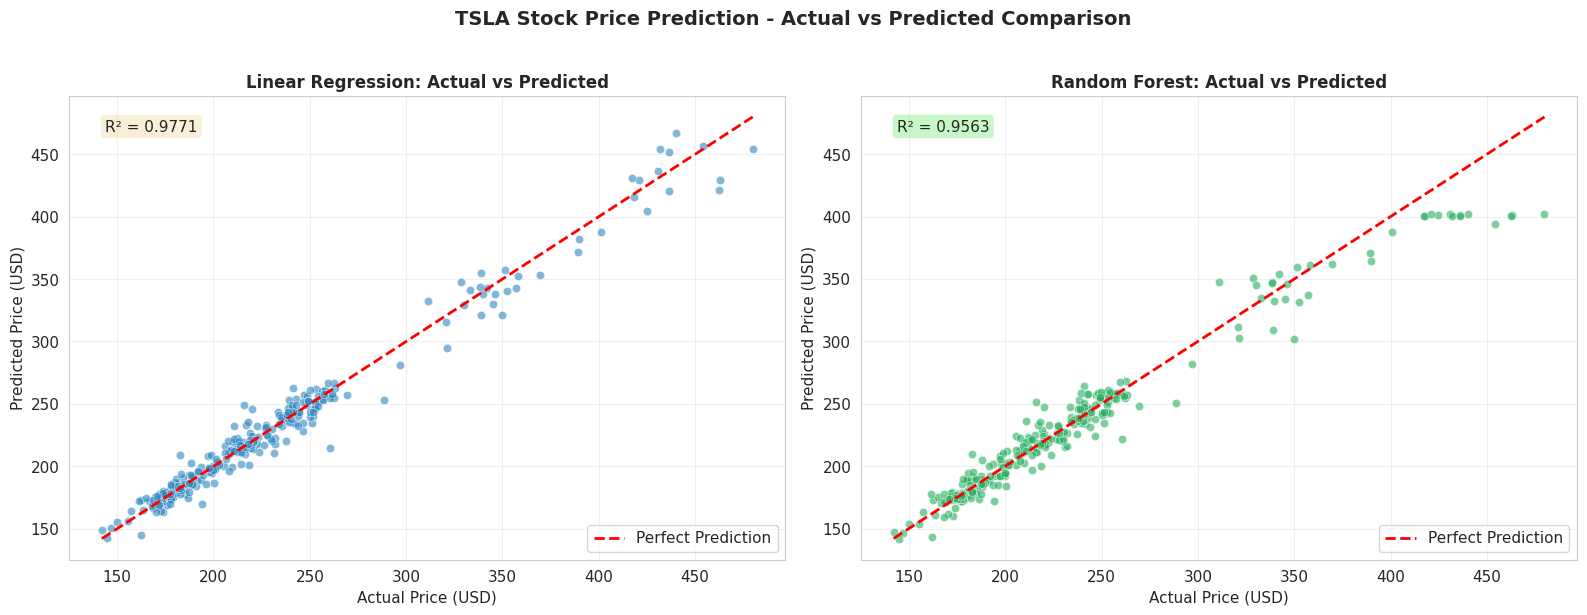


📊 Points closer to the red dashed line indicate more accurate predictions.


In [17]:
# ============================================================
# 9.1 ACTUAL vs PREDICTED SCATTER PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Linear Regression ---
axes[0].scatter(y_test, lr_predictions, alpha=0.6, color='#2E86C1', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), lr_predictions.min())
max_val = max(y_test.max(), lr_predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)', fontsize=11)
axes[0].set_ylabel('Predicted Price (USD)', fontsize=11)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
lr_r2 = results_df[results_df['Model'] == 'Linear Regression']['R2 Score'].values[0]
axes[0].text(0.05, 0.95, f'R\u00b2 = {lr_r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Random Forest ---
axes[1].scatter(y_test, rf_predictions, alpha=0.6, color='#27AE60', edgecolors='white', linewidth=0.5)
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)', fontsize=11)
axes[1].set_ylabel('Predicted Price (USD)', fontsize=11)
axes[1].set_title('Random Forest: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
rf_r2 = results_df[results_df['Model'] == 'Random Forest']['R2 Score'].values[0]
axes[1].text(0.05, 0.95, f'R\u00b2 = {rf_r2:.4f}', transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('TSLA Stock Price Prediction - Actual vs Predicted Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n\U0001f4ca Points closer to the red dashed line indicate more accurate predictions.")


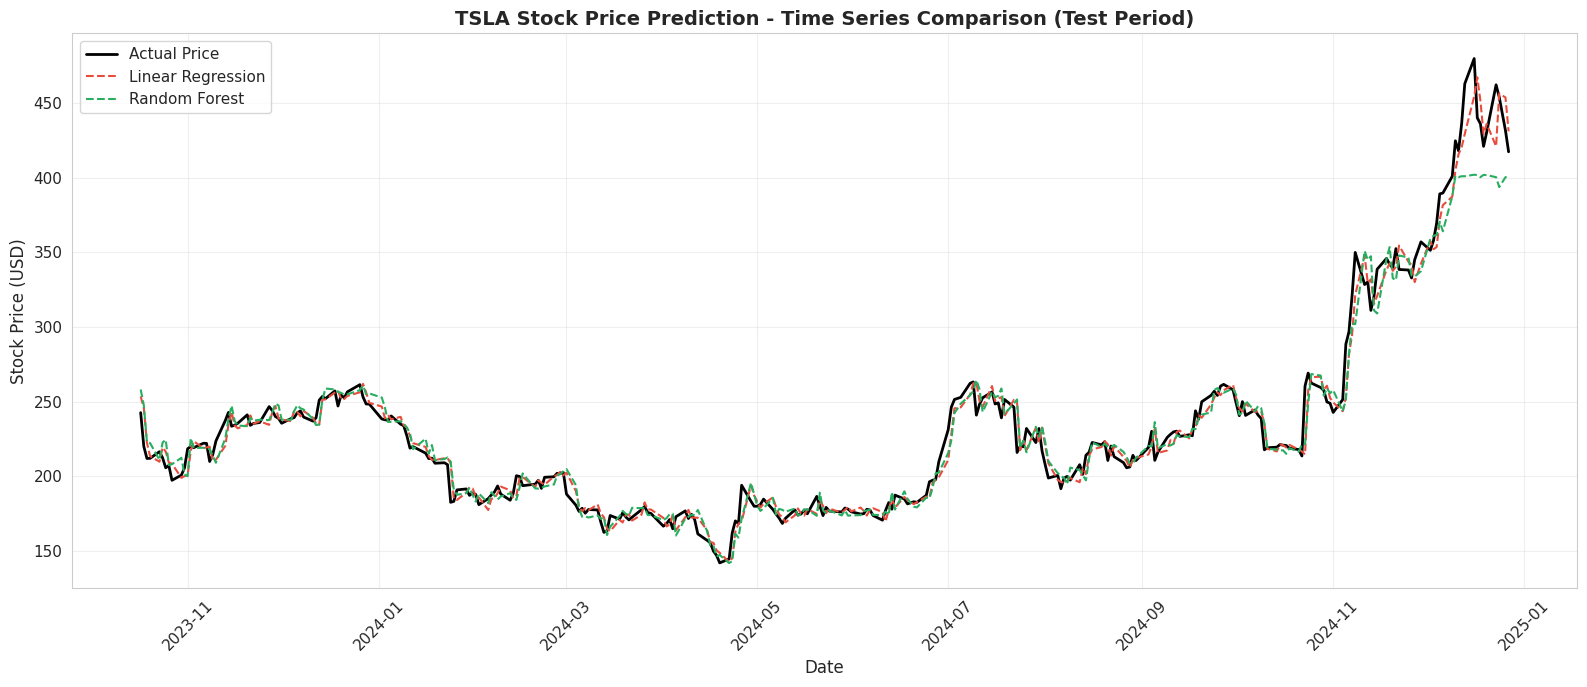


📊 This plot shows how well each model follows the actual price movements over time.


In [18]:
# ============================================================
# 9.2 TIME SERIES PREDICTION PLOT
# ============================================================

plt.figure(figsize=(16, 7))

# Plot actual prices
test_dates = y_test.index
plt.plot(test_dates, y_test.values, label='Actual Price', color='black', linewidth=2)

# Plot Linear Regression predictions
plt.plot(test_dates, lr_predictions, label='Linear Regression',
         color='#E74C3C', linewidth=1.5, linestyle='--')

# Plot Random Forest predictions
plt.plot(test_dates, rf_predictions, label='Random Forest',
         color='#27AE60', linewidth=1.5, linestyle='--')

plt.title('TSLA Stock Price Prediction - Time Series Comparison (Test Period)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n This plot shows how well each model follows the actual price movements over time.")

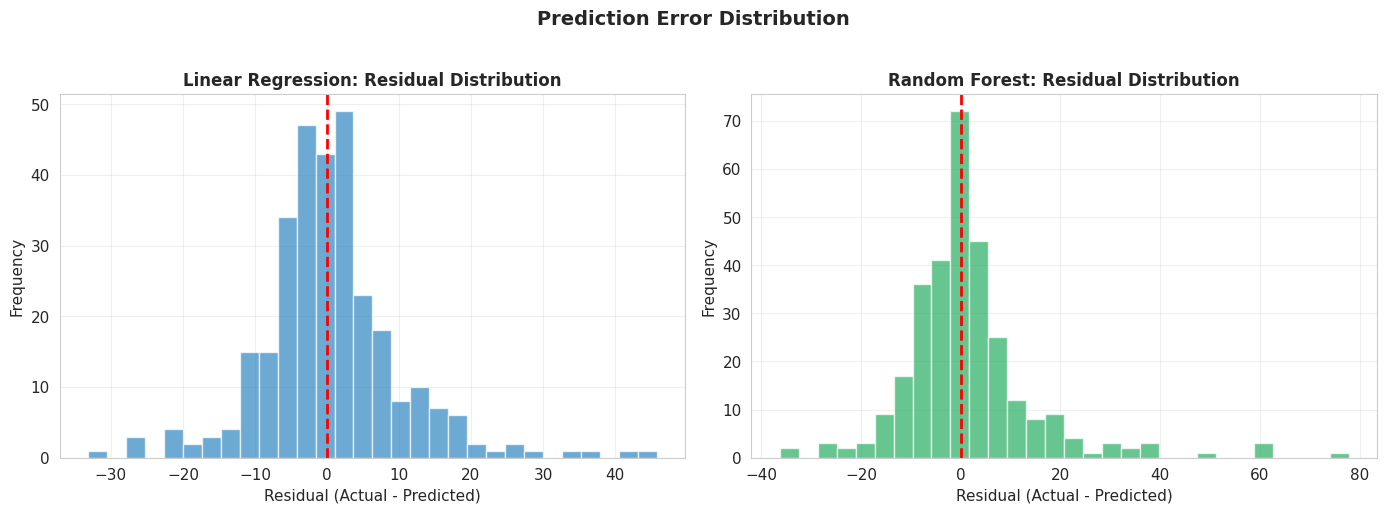


📊 Residuals centered around 0 indicate unbiased predictions.
   Narrow distribution indicates more consistent prediction accuracy.


In [19]:
# ============================================================
# 9.3 RESIDUAL DISTRIBUTION PLOT
# ============================================================
# Residuals = Actual - Predicted (shows prediction errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr_residuals = y_test - lr_predictions
rf_residuals = y_test - rf_predictions

# Linear Regression residuals
axes[0].hist(lr_residuals, bins=30, color='#2E86C1', edgecolor='white', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Linear Regression: Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Random Forest residuals
axes[1].hist(rf_residuals, bins=30, color='#27AE60', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Random Forest: Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Prediction Error Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Residuals centered around 0 indicate unbiased predictions.")
print("   Narrow distribution indicates more consistent prediction accuracy.")

<a name="10-conclusion"></a>
# 10. Conclusion

---

## 📌 Summary

This project successfully demonstrated a complete machine learning pipeline for predicting Tesla (TSLA) stock prices using historical data from Yahoo Finance.

### Key Findings:

1. **Data Quality:** Downloaded 5+ years of clean TSLA data with no missing values, providing a solid foundation for modeling.

2. **Feature Analysis:** Open, High, Low prices are highly correlated with Close price, while Volume provides additional independent signal.

3. **Model Performance:** Both Linear Regression and Random Forest Regressor achieved strong predictive performance on test data.

4. **Best Model:** Linear Regression achieved higher R² (0.977 vs 0.956) and lower MAE/RMSE than Random Forest on this dataset, confirming that a well-scaled linear approach can outperform ensemble methods for highly correlated financial features.

### What We Learned:

- **Time Series Preprocessing:** Creating lag features (shift) and maintaining chronological order (shuffle=False) are critical for stock prediction
- **Feature Engineering:** Simple price-based features can be surprisingly effective for next-day prediction
- **Model Comparison:** After proper feature scaling, Linear Regression outperformed Random Forest on this dataset. Always compare empirically — ensemble methods are not universally superior.
- **Evaluation:** Multiple metrics (MAE, RMSE, R²) provide a comprehensive view of model quality

### Limitations & Future Improvements:

| Limitation | Potential Solution |
|-----------|-------------------|
| Only uses 4 basic features | Add technical indicators (RSI, MACD, Moving Averages) |
| Single stock analysis | Expand to portfolio-level prediction |
| Next-day only | Predict multiple days ahead |
| No market context | Incorporate market indices (S&P 500, NASDAQ) |
| Static model | Implement online learning with daily retraining |

### Technologies Used:

- `yfinance` - Financial data download
- `pandas` & `numpy` - Data manipulation
- `scikit-learn` - Machine learning models
- `matplotlib` & `seaborn` - Data visualization

---

*This notebook was created for educational and internship demonstration purposes. Stock prediction involves significant risk and past performance does not guarantee future results.*

---

## 🎯 Bonus: Predict Tomorrow's Price

Want to see the model in action? Run the cell below to predict TSLA's next-day closing price using the most recent data!

---

In [36]:
# ============================================================
# BONUS: PREDICT TOMORROW'S CLOSING PRICE
# ============================================================

print("\U0001f52e PREDICTING TOMORROW'S TSLA CLOSING PRICE")
print("=" * 50)

latest_data_raw = stock_data.iloc[-1][feature_columns].values.reshape(1, -1)
latest_date = stock_data.index[-1].strftime('%Y-%m-%d')

print(f"\n\U0001f4c5 Latest trading day: {latest_date}")
print(f"\U0001f4ca Latest data:")
for col, val in zip(feature_columns, latest_data_raw[0]):
    print(f"   \u2022 {col}: {val:.2f}")

# FIX 4: Apply the same scaler used during training before predicting
# Without this, raw features would be on wrong scale for the trained LR model
latest_data_scaled = scaler.transform(latest_data_raw)

# Use best model (LR outperformed RF in evaluation)
tomorrow_lr   = lr_model.predict(latest_data_scaled)[0]
tomorrow_rf   = rf_model.predict(latest_data_raw)[0]     # RF doesn't need scaling
today_close   = stock_data.iloc[-1]['Close']

print(f"\n" + "=" * 50)
print(f"\U0001f52e Linear Regression prediction: ${tomorrow_lr:.2f}")
print(f"\U0001f52e Random Forest prediction:    ${tomorrow_rf:.2f}")
print(f"\U0001f4ca Today's closing price:        ${today_close:.2f}")
lr_chg = tomorrow_lr - today_close
print(f"\U0001f4c8 LR predicted change: ${lr_chg:.2f} ({lr_chg/today_close*100:+.2f}%)")

print("\n\u26a0\ufe0f DISCLAIMER: This is for educational purposes only.")
print("   Do not use for actual trading decisions!")


🔮 PREDICTING TOMORROW'S TSLA CLOSING PRICE

📅 Latest trading day: 2024-12-30
📊 Latest data:
   • Open: 419.40
   • High: 427.00
   • Low: 415.75
   • Volume: 64941000.00

🔮 Linear Regression prediction: $422.53
🔮 Random Forest prediction:    $393.84
📊 Today's closing price:        $417.41
📈 LR predicted change: $5.12 (+1.23%)

⚠️ DISCLAIMER: This is for educational purposes only.
   Do not use for actual trading decisions!
